In [1]:
!pip install windpowerlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 5.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from windpowerlib import ModelChain, WindTurbine
from windpowerlib import data as wt

In [3]:
Weather_Data = pd.read_csv('weather-montreal.csv', index_col = 0, header = [0,1],date_parser = lambda idx: pd.to_datetime(idx, utc = True) ) #date_parser = lambda idx: pd.to_datetime(idx, utc = True)
Weather_Data

/tmp/ipykernel_2234/1389978500.py:1: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  Weather_Data = pd.read_csv('weather-montreal.csv', index_col = 0, header = [0,1],date_parser = lambda idx: pd.to_datetime(idx, utc = True) ) #date_parser = lambda idx: pd.to_datetime(idx, utc = True)


variable_name,pressure,temperature,wind_speed,roughness_length,temperature,wind_speed
height,0,2,10,0,10,50
2019-01-01 00:00:00+00:00,99760,273.37,7.11,0.15,273.27,9.85
2019-01-01 01:00:00+00:00,99480,273.56,6.87,0.15,273.46,10.08
2019-01-01 02:00:00+00:00,99200,273.58,6.21,0.15,273.48,9.27
2019-01-01 03:00:00+00:00,98910,273.61,3.66,0.15,273.51,6.51
2019-01-01 04:00:00+00:00,98760,273.58,1.26,0.15,273.48,2.28
...,...,...,...,...,...,...
2019-12-31 19:00:00+00:00,99430,271.17,2.39,0.15,271.07,3.93
2019-12-31 20:00:00+00:00,99400,271.35,2.59,0.15,271.25,4.69
2019-12-31 21:00:00+00:00,99370,271.69,3.28,0.15,271.59,6.39


In [4]:
Turbine_lib = wt.get_turbine_types()


       manufacturer  turbine_type  has_power_curve  has_cp_curve
0       Adwen/Areva    AD116/5000             True         False
1           Enercon    E-101/3050             True          True
2           Enercon    E-101/3500             True          True
3           Enercon    E-115/3000             True          True
4           Enercon    E-115/3200             True          True
5           Enercon    E-126/4200             True          True
6           Enercon    E-126/7500             True         False
7           Enercon    E-126/7580             True         False
8           Enercon    E-141/4200             True          True
9           Enercon      E-53/800             True          True
10          Enercon     E-70/2000             True         False
11          Enercon     E-70/2300             True          True
12          Enercon     E-82/2000             True          True
13          Enercon     E-82/2300             True          True
14          Enercon     E

/usr/local/lib/python3.13/dist-packages/windpowerlib/data.py:103: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ).fillna(False)


In [5]:
Selected_Turbine = {'turbine_type':'E48/800','hub_height':60}
W_Turbine = WindTurbine(**Selected_Turbine)

In [6]:
Wind_Sub_Model = {
    'wind_speed_model':'hellman',
    'density_model':'ideal_gas',
    'temperature_model':'linear_gradient',
    'power_output_model':'power_coefficient_curve',
    'density_correction':True,
    'obstacle_height':0,
    'hellman_exp':.25
}

In [7]:
Model = ModelChain(W_Turbine,**Wind_Sub_Model).run_model(Weather_Data)

In [8]:
Turbine_Power_Output = (Model.power_output)/1000
Turbine_Power_Output

,feedin_power_plant
2019-01-01 00:00:00+00:00,607.007263
2019-01-01 01:00:00+00:00,632.135315
2019-01-01 02:00:00+00:00,518.769474
2019-01-01 03:00:00+00:00,167.707041
2019-01-01 04:00:00+00:00,1.009322
...,...
2019-12-31 19:00:00+00:00,28.706123
2019-12-31 20:00:00+00:00,57.379249
2019-12-31 21:00:00+00:00,160.043377
2019-12-31 22:00:00+00:00,289.477526


In [9]:
Wind = (Model.wind_speed_hub(Weather_Data))
Wind

,50
2019-01-01 00:00:00+00:00,10.309356
2019-01-01 01:00:00+00:00,10.550082
2019-01-01 02:00:00+00:00,9.702308
2019-01-01 03:00:00+00:00,6.813595
2019-01-01 04:00:00+00:00,2.386328
...,...
2019-12-31 19:00:00+00:00,4.113276
2019-12-31 20:00:00+00:00,4.908719
2019-12-31 21:00:00+00:00,6.687999
2019-12-31 22:00:00+00:00,8.069557


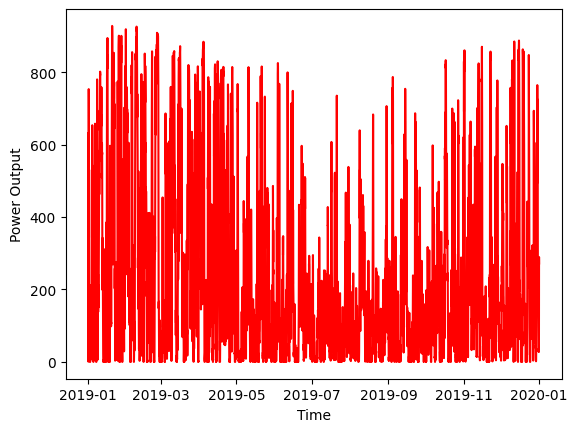

In [10]:
plt.plot(Turbine_Power_Output, c='r')
plt.xlabel('Time')
plt.ylabel('Power Output')
plt.show()